GLOSARIO DE VARIABLES REM20
 PERIODO                        → Año del registro
 TIPO_PERTENENCIA               → Tipo de establecimiento (1=público, 2=privado, etc.)
 COD_SSS / GLOSA_SSS            → Código y nombre del Servicio de Salud al que pertenece
 CODIGO_ESTABLECIMIENTO         → Código único del hospital
 ESTABLECIMIENTO                → Nombre del hospital
 COD_AREA_FUNCIONAL             → Código del área clínica dentro del hospital
 AREA_FUNCIONAL                 → Nombre del área clínica (ej: UCI Adultos, Obstetricia)
 MES                            → Mes del registro (1-12)
 DIAS_CAMAS_OCUPADAS            → Total de días que las camas estuvieron ocupadas en el mes
 DIAS_CAMAS_DISPONIBLES         → Total de días que las camas estuvieron disponibles
 DIAS_ESTADA                    → Suma de días de hospitalización de todos los egresos
 NUMERO_EGRESOS                 → Cantidad de pacientes egresados (altas + fallecidos + traslados)
 EGRESOS_FALLECIDOS             → Egresos p

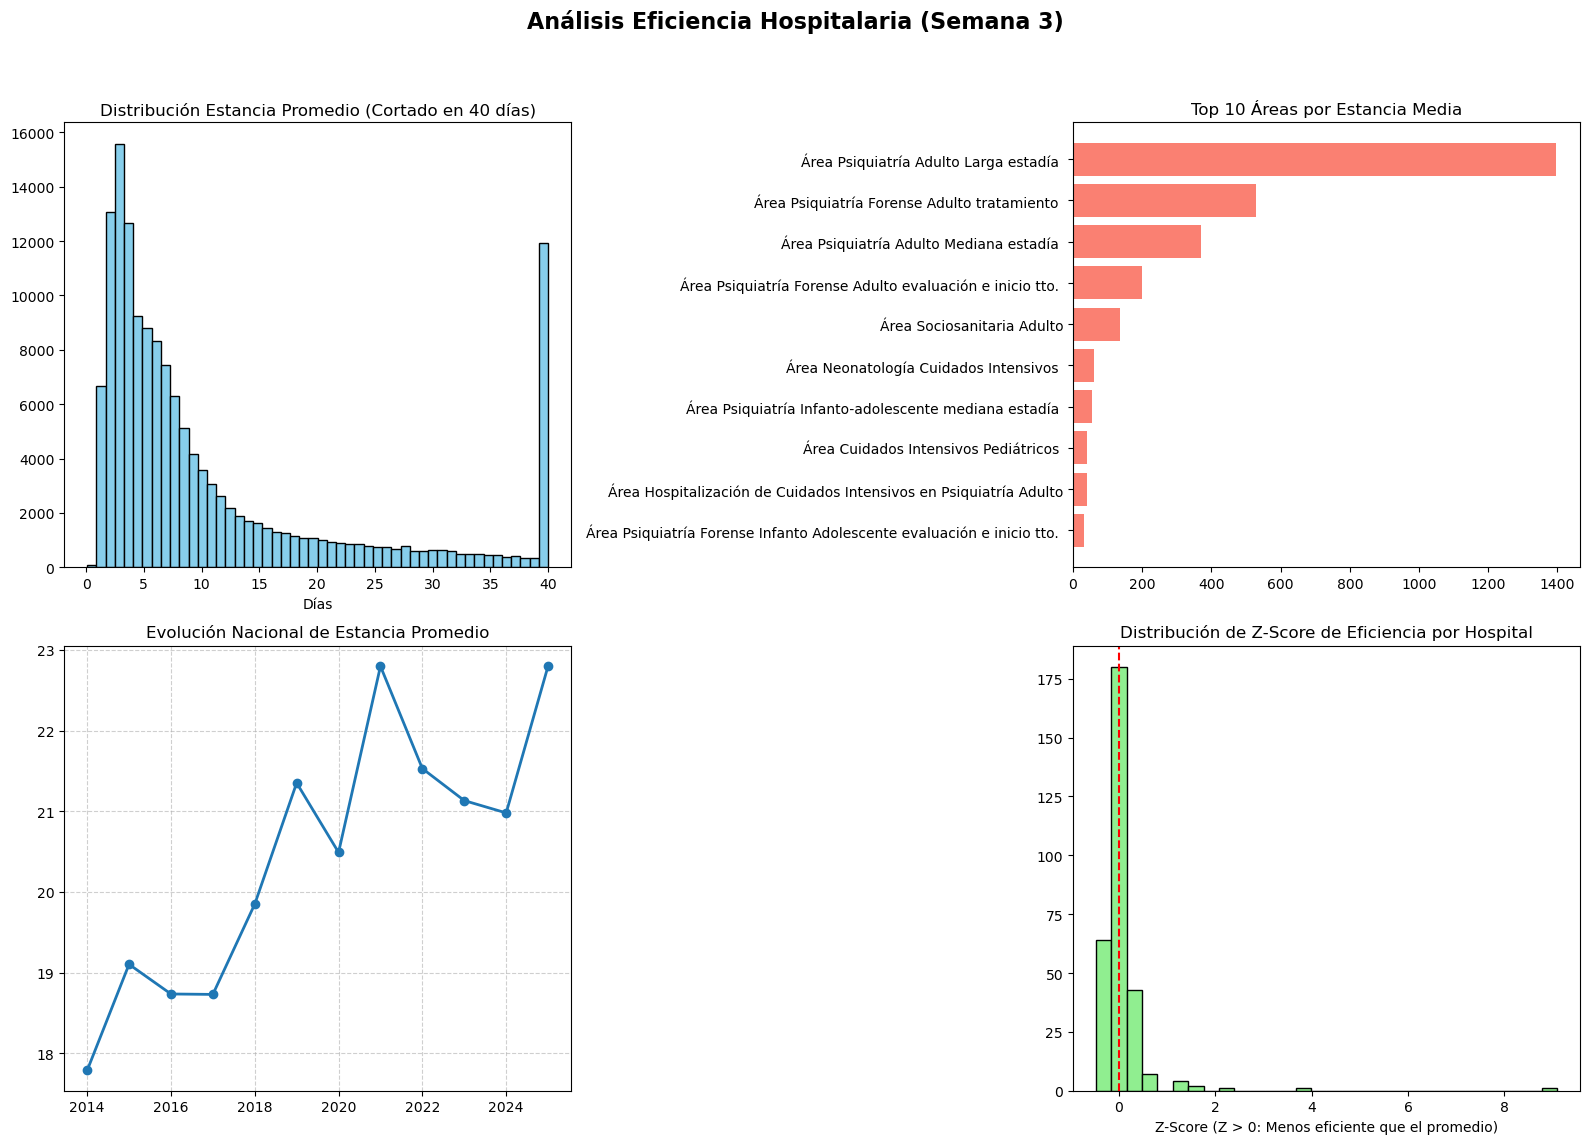

In [ ]:

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import warnings
import os

warnings.filterwarnings('ignore')


# 0. GLOSARIO DE VARIABLES
GLOSARIO = {
    "PERIODO": "Año del registro",
    "TIPO_PERTENENCIA": "Tipo de establecimiento (1=público, 2=privado, etc.)",
    "COD_SSS / GLOSA_SSS": "Código y nombre del Servicio de Salud al que pertenece",
    "CODIGO_ESTABLECIMIENTO": "Código único del hospital",
    "ESTABLECIMIENTO": "Nombre del hospital",
    "COD_AREA_FUNCIONAL": "Código del área clínica dentro del hospital",
    "AREA_FUNCIONAL": "Nombre del área clínica (ej: UCI Adultos, Obstetricia)",
    "MES": "Mes del registro (1-12)",
    "DIAS_CAMAS_OCUPADAS": "Total de días que las camas estuvieron ocupadas en el mes",
    "DIAS_CAMAS_DISPONIBLES": "Total de días que las camas estuvieron disponibles",
    "DIAS_ESTADA": "Suma de días de hospitalización de todos los egresos",
    "NUMERO_EGRESOS": "Cantidad de pacientes egresados (altas + fallecidos + traslados)",
    "EGRESOS_FALLECIDOS": "Egresos por fallecimiento",
    "TRASLADOS": "Pacientes trasladados a otro establecimiento",
    "INDICE_OCUPACIONAL": "% de camas ocupadas",
    "PROMEDIO_CAMAS_DISPONIBLE": "Promedio de camas disponibles en el mes",
    "PROMEDIO_DIAS_ESTADA": "Promedio de días que un paciente permaneció hospitalizado",
    "LETALIDAD": "% de egresos que son fallecidos",
    "INDICE_ROTACION": "Egresos por cama disponible",
}

print("=" * 70)
print("GLOSARIO DE VARIABLES REM20")
print("=" * 70)
for var, desc in GLOSARIO.items():
    print(f" {var:<30} → {desc}")
print()


# 1. IMPORTACIÓN Y LIMPIEZA

print("=" * 70)
print("1. IMPORTACIÓN Y LIMPIEZA")
print("=" * 70)


try:
    df = pd.read_csv("indicadores_rem20_20260225.csv", sep=";")
except FileNotFoundError:
    print("Error: No se encontró el archivo 'indicadores_rem20_20260225.csv'.")
    exit()

print(f" Filas cargadas : {len(df):,}")
print(f" Hospitales únicos : {df['ESTABLECIMIENTO'].nunique()}")

antes = len(df)
df = df[df["NUMERO_EGRESOS"] > 0].copy()
df = df[df["PROMEDIO_DIAS_ESTADA"] > 0].copy()
print(f" Filas eliminadas (egresos=0 o estancia inválida): {antes - len(df):,}")


# 2. ANÁLISIS DESCRIPTIVO

print("\n" + "=" * 70)
print("2. ANÁLISIS DESCRIPTIVO DE VARIABLES CLAVE")
print("=" * 70)
vars_clave = ["PROMEDIO_DIAS_ESTADA", "INDICE_OCUPACIONAL", "INDICE_ROTACION"]
print(df[vars_clave].describe().round(2).to_string())


# 3. ESTANCIA POR ÁREA FUNCIONAL

print("\n" + "=" * 70)
print("3. ESTANCIA PROMEDIO POR ÁREA FUNCIONAL")
print("=" * 70)
por_area = df.groupby("AREA_FUNCIONAL").agg(
    estancia_media=("PROMEDIO_DIAS_ESTADA", "mean"),
    n_registros=("PROMEDIO_DIAS_ESTADA", "count")
).round(2).sort_values("estancia_media", ascending=False)
print(por_area.head(10).to_string())


# 4. VARIABILIDAD (Coeficiente de Variación)

print("\n" + "=" * 70)
print("4. VARIABILIDAD ENTRE HOSPITALES (Misma área)")
print("=" * 70)
area_counts = df.groupby("AREA_FUNCIONAL")["ESTABLECIMIENTO"].nunique()
areas_comparables = area_counts[area_counts >= 20].index

variabilidad = []
for area in areas_comparables:
    sub = df[df["AREA_FUNCIONAL"] == area]
    hosp_stats = sub.groupby("ESTABLECIMIENTO")["PROMEDIO_DIAS_ESTADA"].mean()
    cv = (hosp_stats.std() / hosp_stats.mean()) * 100
    variabilidad.append({"area": area, "n_hosp": len(hosp_stats), "cv_%": cv.round(1)})

df_variab = pd.DataFrame(variabilidad).sort_values("cv_%", ascending=False)
print(df_variab.head(10).to_string(index=False))


# 5. CÁLCULO DE Z-SCORE (Eficiencia Relativa)

df["z_estancia"] = df.groupby("AREA_FUNCIONAL")["PROMEDIO_DIAS_ESTADA"].transform(
    lambda x: (x - x.mean()) / x.std() if x.std() > 0 else 0
)

z_por_hospital = df.groupby("ESTABLECIMIENTO")["z_estancia"].agg(["mean", "count"]).query("count >= 24")
z_por_hospital = z_por_hospital.sort_values("mean", ascending=False)


# 6. Graficos



fig, axes = plt.subplots(2, 2, figsize=(16, 12))
fig.suptitle("Análisis Eficiencia Hospitalaria", fontsize=16, fontweight='bold')


ax1 = axes[0, 0]
ax1.hist(df["PROMEDIO_DIAS_ESTADA"].clip(upper=40), bins=50, color="skyblue", edgecolor="black")
ax1.set_title("Distribución Estancia Promedio (Cortado en 40 días)")
ax1.set_xlabel("Días")


ax2 = axes[0, 1]
top_10_areas = por_area.head(10)
ax2.barh(top_10_areas.index, top_10_areas["estancia_media"], color="salmon")
ax2.set_title("Top 10 Áreas por Estancia Media")
ax2.invert_yaxis()


ax3 = axes[1, 0]
evolucion = df.groupby("PERIODO")["PROMEDIO_DIAS_ESTADA"].mean()
ax3.plot(evolucion.index, evolucion.values, marker='o', linewidth=2)
ax3.set_title("Evolución Nacional de Estancia Promedio")
ax3.grid(True, linestyle='--', alpha=0.6)


ax4 = axes[1, 1]
ax4.hist(z_por_hospital["mean"], bins=30, color="lightgreen", edgecolor="black")
ax4.axvline(0, color="red", linestyle="--")
ax4.set_title("Distribución de Z-Score de Eficiencia por Hospital")
ax4.set_xlabel("Z-Score (Z > 0: Menos eficiente que el promedio)")

plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.savefig("semana3_analisis.png", dpi=150)
print(" ✓ Gráficas guardadas como 'semana3_analisis.png'")


# 7. RESUMEN FINAL

print("\n" + "=" * 70)
print("7. HALLAZGOS PRELIMINARES")
print("=" * 70)
print(f"Hospitales con estancia significativamente larga (Z > 1): {len(z_por_hospital[z_por_hospital['mean'] > 1])}")
print(f"Hospitales con estancia significativamente corta (Z < -1): {len(z_por_hospital[z_por_hospital['mean'] < -1])}")
print("\nAnálisis completado. Listo para definir hipótesis en Semana 4.")